# Humanitarian Funding Alignment Analysis per Sector

The goal of this section is to get one level deeper into the analysis since it's not only important to know which countries are over/underfunded, it's also extremely important to know which cluster requires attention. Since the CBPT hand out money based on the organization which applies for it, it's very important which type of organization gets the money and that all issues in the country sufficiently covered. 

### The alignment ratio

For every country-sector combination, we compute an **alignment ratio**:

$$\text{alignment ratio} = \frac{\text{funding share}}{\text{need share}}$$

where:
- **Need share** = sector's People-in-Need / country's total People-in-Need (from HNO data)
- **Funding share** = (sector's CERF + CBPF allocation) / (country's total CERF + CBPF allocation)

The interpretation is intuitive:

| Ratio | Meaning |
|-------|----------|
| **= 1.0** | Sector receives funding exactly proportional to its share of need |
| **> 1.0** | Sector is *overfunded* relative to its share of need |
| **< 1.0** | Sector is *underfunded* relative to its share of need |
| **= 0** | Sector has people in need but receives zero funding |

### Rolling up to a country-level score

To collapse sector-level ratios into a single number per country, we use a **needs-weighted log-deviation** formula:

$$\text{misalignment} = \sum_s |\log(\text{ratio}_s)| \times \text{need\_share}_s$$

$$\text{alignment score} = e^{-\text{misalignment}}$$

- **Log** ensures symmetry: overfunding by 2x and underfunding by 0.5x are treated as equal distortions.
- **Needs-weighting** ensures that misallocation in large sectors matters more than in small ones.
- The final score ranges from **0 to 1**, where **1.0 = perfectly proportional funding**.

### Data sources

Data for this was retreived from the CBPT and CERF allocations, as well as a HNO dataset.

## Setup and Calculations


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
%matplotlib inline

DATA_DIR = Path("data")

In [5]:
CLUSTER_CODE_TO_NAME = {
    "EDU": "Education",
    "FSC": "Food Security",
    "HEA": "Health",
    "NUT": "Nutrition",
    "PRO": "Protection",
    "SHL": "Shelter/NFI",
    "WSH": "WASH",
    "CCM": "CCCM",
    "ERY": "Early Recovery",
    "MS":  "Multi-Sector",
    "MPC": "Multipurpose Cash",
}

CBPF_COUNTRY_TO_ISO3 = {
    "Afghanistan": "AFG", "Bangladesh": "BGD", "Burkina Faso": "BFA",
    "CAR": "CAF", "Chad (RhPF)": "TCD", "Colombia": "COL",
    "Colombia (RhPF)": "COL", "DRC": "COD", "Ethiopia": "ETH",
    "Fiji": "FJI", "Haiti": "HTI", "Haiti (RhPF)": "HTI",
    "Iraq": "IRQ", "Jordan": "JOR", "Kenya": "KEN", "Lebanon": "LBN",
    "Mali": "MLI", "Mozambique (RhPF)": "MOZ", "Myanmar": "MMR",
    "Niger": "NER", "Nigeria": "NGA", "Pakistan": "PAK",
    "Somalia": "SOM", "South Sudan": "SSD", "Sudan": "SDN",
    "Syria": "SYR", "Syria Cross border": "SYR", "Uganda": "UGA",
    "Ukraine": "UKR", "Venezuela": "VEN", "Yemen": "YEM", "oPt": "PSE",
}

# Clusters to exclude from the analysis
EXCLUDE_CLUSTERS = ["Multipurpose Cash", "Early Recovery"]

In [6]:
hno_raw = pd.read_csv(DATA_DIR / "hno_comb_cleaned.csv", low_memory=False)
hno_raw.columns = hno_raw.columns.str.strip()

print(f"Raw HNO rows: {len(hno_raw):,}")
print(f"Columns: {list(hno_raw.columns)}")
hno_raw.head(3)

Raw HNO rows: 452,932
Columns: ['Country ISO3', 'Admin 1 PCode', 'Admin 1 Name', 'Admin 2 PCode', 'Admin 2 Name', 'Admin 3 PCode', 'Admin 3 Name', 'Description', 'Cluster', 'Category', 'Population', 'In Need', 'Targeted', 'Affected', 'Reached', 'Info', 'Cluster_Original']


,Country ISO3,Admin 1 PCode,Admin 1 Name,Admin 2 PCode,Admin 2 Name,Admin 3 PCode,Admin 3 Name,Description,Cluster,Category,Population,In Need,Targeted,Affected,Reached,Info,Cluster_Original
0,AFG,NaN,NaN,NaN,NaN,NaN,NaN,Education,Education,NaN,NaN,8030371,1350000,NaN,NaN,NaN,EDU
1,AFG,NaN,NaN,NaN,NaN,NaN,NaN,Education,Education,Children,NaN,8030371,1350000,NaN,NaN,NaN,EDU
2,AFG,NaN,NaN,NaN,NaN,NaN,NaN,Education,Education,Children - Female,NaN,4031751,677785,NaN,NaN,NaN,EDU


In [7]:
# Filter to national-level, no-category rows
mask = (
    hno_raw["Admin 1 PCode"].isna()
    & hno_raw["Admin 2 PCode"].isna()
    & hno_raw["Admin 3 PCode"].isna()
    & hno_raw["Category"].isna()
)
hno_nat = hno_raw[mask][["Country ISO3", "Cluster", "In Need"]].copy()
hno_nat = hno_nat[hno_nat["Country ISO3"] != "#country+code"]
hno_nat["In Need"] = pd.to_numeric(hno_nat["In Need"], errors="coerce")
hno_nat = hno_nat.dropna(subset=["In Need"])
hno_nat = hno_nat[hno_nat["In Need"] > 0]

# Exclude unwanted clusters
hno_nat = hno_nat[~hno_nat["Cluster"].isin(EXCLUDE_CLUSTERS)]

# Average across duplicate entries per country-cluster
needs = (
    hno_nat.groupby(["Country ISO3", "Cluster"], as_index=False)["In Need"]
    .mean()
    .rename(columns={"Country ISO3": "country", "Cluster": "cluster", "In Need": "pin"})
)

print(f"National-level needs: {len(needs)} country-cluster pairs")
print(f"Countries: {sorted(needs['country'].unique())}")
print(f"Clusters: {sorted(needs['cluster'].unique())}")
needs.head(10)

National-level needs: 193 country-cluster pairs
Countries: ['AFG', 'BFA', 'CAF', 'CMR', 'COD', 'COL', 'ETH', 'GTM', 'HND', 'HTI', 'MLI', 'MMR', 'MOZ', 'NER', 'NGA', 'SDN', 'SLV', 'SOM', 'SSD', 'SYR', 'TCD', 'UKR', 'VEN', 'YEM']
Clusters: ['CCCM', 'Education', 'Food Security', 'Health', 'Multi-Sector', 'Nutrition', 'Protection', 'Shelter/NFI', 'WASH']


,country,cluster,pin
0,AFG,Education,8.007806e+06
1,AFG,Food Security,1.600035e+07
2,AFG,Health,1.554665e+07
3,AFG,Multi-Sector,4.150000e+05
4,AFG,Nutrition,7.555281e+06
5,AFG,Protection,1.741527e+07
6,AFG,Shelter/NFI,5.536915e+06
7,AFG,WASH,1.932970e+07
8,BFA,CCCM,1.241925e+06
9,BFA,Education,2.094860e+06


In [8]:
cerf_raw = pd.read_csv(DATA_DIR / "cerf_allocations_cleaned.csv", low_memory=False)
cerf_raw.columns = cerf_raw.columns.str.strip()
cerf_raw["totalAmountApproved"] = pd.to_numeric(cerf_raw["totalAmountApproved"], errors="coerce").fillna(0)
cerf_raw["cluster_name"] = cerf_raw["Cluster"].map(CLUSTER_CODE_TO_NAME)
cerf_raw = cerf_raw[~cerf_raw["cluster_name"].isin(EXCLUDE_CLUSTERS)]

cerf = (
    cerf_raw.groupby(["countryCode", "cluster_name"], as_index=False)["totalAmountApproved"]
    .sum()
    .rename(columns={"countryCode": "country", "cluster_name": "cluster",
                     "totalAmountApproved": "funding"})
    .dropna(subset=["cluster"])
)

print(f"CERF funding: {len(cerf)} country-cluster pairs")
print(f"Total CERF: ${cerf['funding'].sum():,.0f}")
cerf.head()

CERF funding: 689 country-cluster pairs
Total CERF: $7,997,939,067


,country,cluster,funding
0,AFG,Food Security,1.485084e+08
1,AFG,Health,7.673327e+07
2,AFG,Multi-Sector,5.390176e+07
3,AFG,Nutrition,1.351466e+07
4,AFG,Protection,1.349142e+07


In [9]:
cbpf_raw = pd.read_csv(DATA_DIR / "cbpf_allocations_clean.csv", low_memory=False)
cbpf_raw.columns = cbpf_raw.columns.str.strip()
cbpf_raw["Budget"] = pd.to_numeric(cbpf_raw["Budget"], errors="coerce").fillna(0)
cbpf_raw["ClusterPercentage"] = pd.to_numeric(cbpf_raw["ClusterPercentage"], errors="coerce").fillna(100)

cbpf_raw["cluster_funding"] = cbpf_raw["Budget"] * cbpf_raw["ClusterPercentage"] / 100.0
cbpf_raw["country"] = cbpf_raw["PooledFundName"].map(CBPF_COUNTRY_TO_ISO3)
cbpf_raw["cluster_name"] = cbpf_raw["Cluster"].map(CLUSTER_CODE_TO_NAME)
cbpf_raw = cbpf_raw[~cbpf_raw["cluster_name"].isin(EXCLUDE_CLUSTERS)]

cbpf = (
    cbpf_raw.groupby(["country", "cluster_name"], as_index=False)["cluster_funding"]
    .sum()
    .rename(columns={"cluster_name": "cluster", "cluster_funding": "funding"})
    .dropna(subset=["country", "cluster"])
)

print(f"CBPF funding: {len(cbpf)} country-cluster pairs")
print(f"Total CBPF: ${cbpf['funding'].sum():,.0f}")
cbpf.head()

CBPF funding: 208 country-cluster pairs
Total CBPF: $85,971,251,473


,country,cluster,funding
0,AFG,Education,1.132916e+08
1,AFG,Food Security,5.001646e+09
2,AFG,Health,5.992322e+09
3,AFG,Multi-Sector,4.138744e+07
4,AFG,Nutrition,4.025973e+09


In [10]:
funding = (
    pd.concat([cerf, cbpf], ignore_index=True)
    .groupby(["country", "cluster"], as_index=False)["funding"]
    .sum()
)

print(f"Combined funding: {len(funding)} country-cluster pairs")
print(f"Total (CERF + CBPF): ${funding['funding'].sum():,.0f}")
funding.head()

Combined funding: 702 country-cluster pairs
Total (CERF + CBPF): $93,969,190,540


,country,cluster,funding
0,AFG,Education,1.132916e+08
1,AFG,Food Security,5.150154e+09
2,AFG,Health,6.069055e+09
3,AFG,Multi-Sector,9.528919e+07
4,AFG,Nutrition,4.039488e+09


In [11]:
merged = needs.merge(funding, on=["country", "cluster"], how="inner")

# Compute shares within each country
country_totals = merged.groupby("country").agg(
    total_pin=("pin", "sum"),
    total_funding=("funding", "sum"),
)
merged = merged.join(country_totals, on="country")
merged["need_share"] = merged["pin"] / merged["total_pin"]
merged["funding_share"] = merged["funding"] / merged["total_funding"]
merged["alignment_ratio"] = merged["funding_share"] / merged["need_share"]

# Drop countries with only 1 matched sector
sector_counts = merged.groupby("country")["cluster"].transform("count")
alignment = merged[sector_counts >= 2].drop(columns=["total_pin", "total_funding"]).copy()

print(f"Alignment table: {len(alignment)} country-cluster pairs "
      f"across {alignment['country'].nunique()} countries")
alignment.sort_values(["country", "alignment_ratio"]).head(15)

Alignment table: 189 country-cluster pairs across 24 countries


,country,cluster,pin,funding,need_share,funding_share,alignment_ratio
0,AFG,Education,8.007806e+06,1.132916e+08,0.089167,0.006095,0.068356
6,AFG,Shelter/NFI,5.536915e+06,1.710458e+08,0.061654,0.009202,0.149257
7,AFG,WASH,1.932970e+07,1.388646e+09,0.215236,0.074709,0.347101
5,AFG,Protection,1.741527e+07,1.560507e+09,0.193919,0.083955,0.432937
3,AFG,Multi-Sector,4.150000e+05,9.528919e+07,0.004621,0.005127,1.109393
1,AFG,Food Security,1.600035e+07,5.150154e+09,0.178164,0.277077,1.555179
2,AFG,Health,1.554665e+07,6.069055e+09,0.173112,0.326513,1.886140
4,AFG,Nutrition,7.555281e+06,4.039488e+09,0.084128,0.217323,2.583244
8,BFA,CCCM,1.241925e+06,9.938993e+05,0.060565,0.003005,0.049620
9,BFA,Education,2.094860e+06,1.084642e+07,0.102161,0.032796,0.321025


In [12]:
score_df = alignment.copy()
score_df["ratio_clamped"] = score_df["alignment_ratio"].clip(lower=1e-6)
score_df["abs_log_dev"] = np.abs(np.log(score_df["ratio_clamped"]))
score_df["weighted_dev"] = score_df["abs_log_dev"] * score_df["need_share"]

scores = score_df.groupby("country")["weighted_dev"].sum().reset_index()
scores.columns = ["country", "misalignment"]
scores["alignment_score"] = np.exp(-scores["misalignment"])

print(scores.sort_values("alignment_score").to_string(index=False))

country  misalignment  alignment_score
    SLV      1.134639         0.321538
    GTM      1.057878         0.347192
    AFG      1.015441         0.362243
    SOM      0.805951         0.446663
    MLI      0.756673         0.469225
    SDN      0.755212         0.469911
    HTI      0.740241         0.476999
    MMR      0.725325         0.484167
    CMR      0.690379         0.501386
    MOZ      0.681420         0.505898
    HND      0.661901         0.515870
    TCD      0.657617         0.518084
    ETH      0.622152         0.536788
    UKR      0.512061         0.599259
    NER      0.498281         0.607574
    BFA      0.498059         0.607709
    NGA      0.480668         0.618370
    CAF      0.380294         0.683660
    YEM      0.357963         0.699099
    COL      0.338605         0.712764
    VEN      0.319131         0.726781
    SYR      0.301972         0.739359
    COD      0.292363         0.746498
    SSD      0.289369         0.748736


---
## Visualisations

### Heatmap -- alignment ratio by country and sector

This is the most detailed view: each cell shows the alignment ratio for one country-sector combination. Values close to 1.0 (white) mean proportional funding. Red cells are underfunded; green cells are overfunded relative to need. 

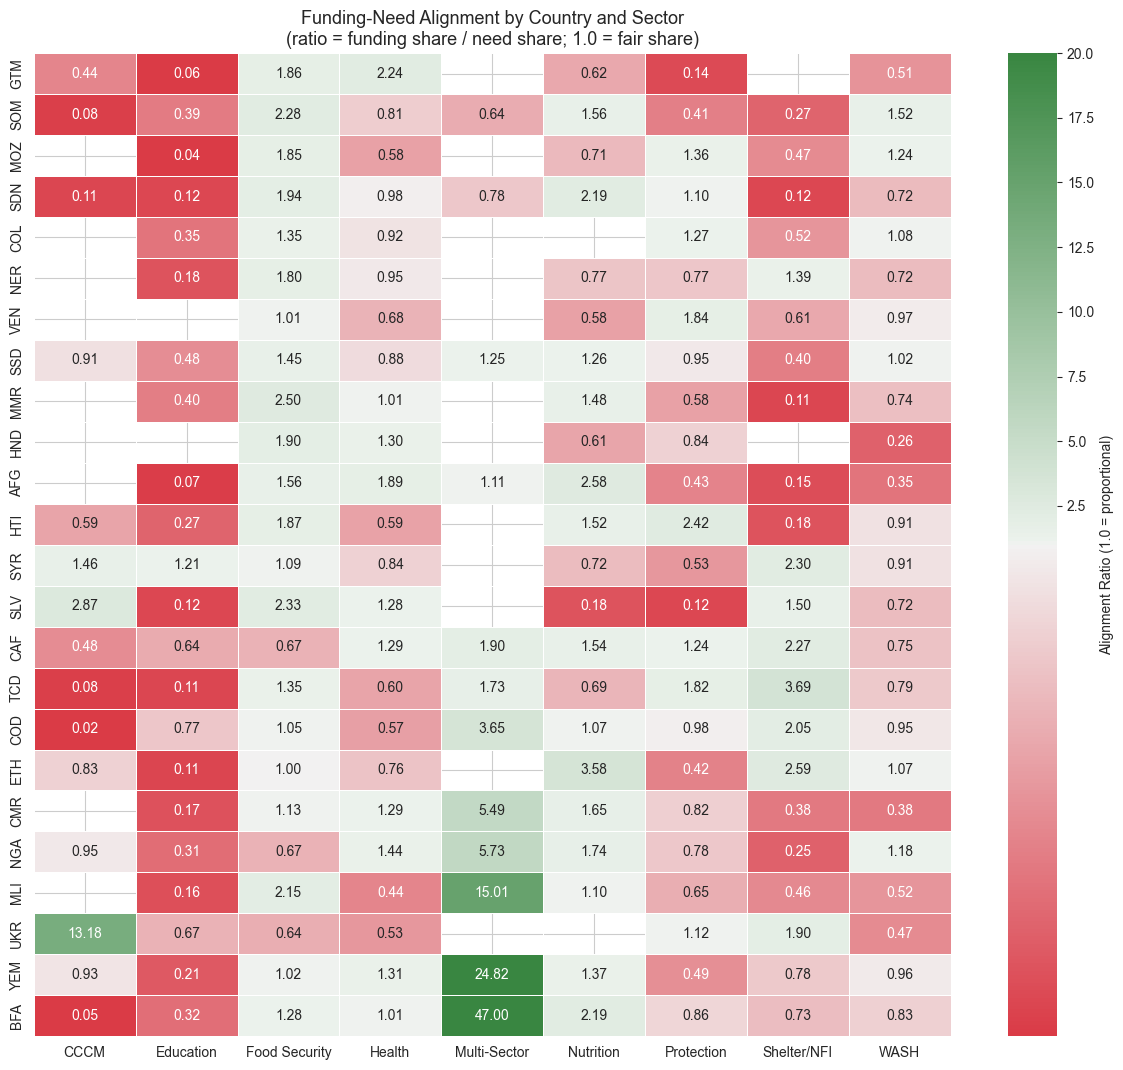

In [19]:
pivot = alignment.pivot_table(index="country", columns="cluster", values="alignment_ratio")
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot) * 0.45)))
norm = mcolors.TwoSlopeNorm(vmin=0.05, vcenter=1.0, vmax=20)
cmap = sns.diverging_palette(10, 130, as_cmap=True)

sns.heatmap(
    pivot, ax=ax, cmap=cmap, norm=norm,
    annot=True, fmt=".2f", linewidths=0.5,
    cbar_kws={"label": "Alignment Ratio (1.0 = proportional)"},
)
ax.set_title("Funding-Need Alignment by Country and Sector\n"
             "(ratio = funding share / need share; 1.0 = fair share)", fontsize=13)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Global sector alignment -- clusters globally under/overfunded?

This chart shows the allignments of these clusters across all countries to see which clusters are systematically under/overfunded.

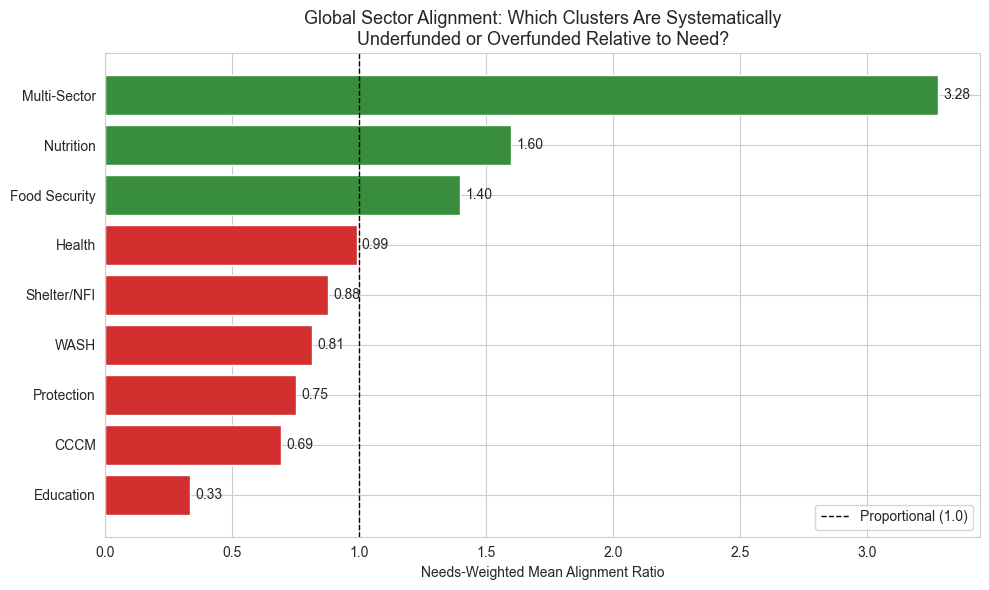

In [14]:
df_global = alignment.copy()
global_pin = df_global["pin"].sum()
df_global["global_need_weight"] = df_global["pin"] / global_pin
df_global["weighted_ratio"] = df_global["alignment_ratio"] * df_global["global_need_weight"]

sector_stats = df_global.groupby("cluster").agg(
    weighted_ratio=("weighted_ratio", "sum"),
    global_weight=("global_need_weight", "sum"),
)
sector_stats["mean_alignment"] = sector_stats["weighted_ratio"] / sector_stats["global_weight"]
sector_stats = sector_stats.sort_values("mean_alignment")

colors = ["#d32f2f" if v < 1 else "#388e3c" for v in sector_stats["mean_alignment"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sector_stats.index, sector_stats["mean_alignment"], color=colors, edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="Proportional (1.0)")
ax.set_xlabel("Needs-Weighted Mean Alignment Ratio")
ax.set_title("Global Sector Alignment: Which Clusters Are Systematically\n"
             "Underfunded or Overfunded Relative to Need?", fontsize=13)
ax.legend()

for bar, val in zip(bars, sector_stats["mean_alignment"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

### Country-level alignment scores

Each country gets a single score (0 to 1) summarising how proportional its funding distribution is to its needs distribution. Higher is better.

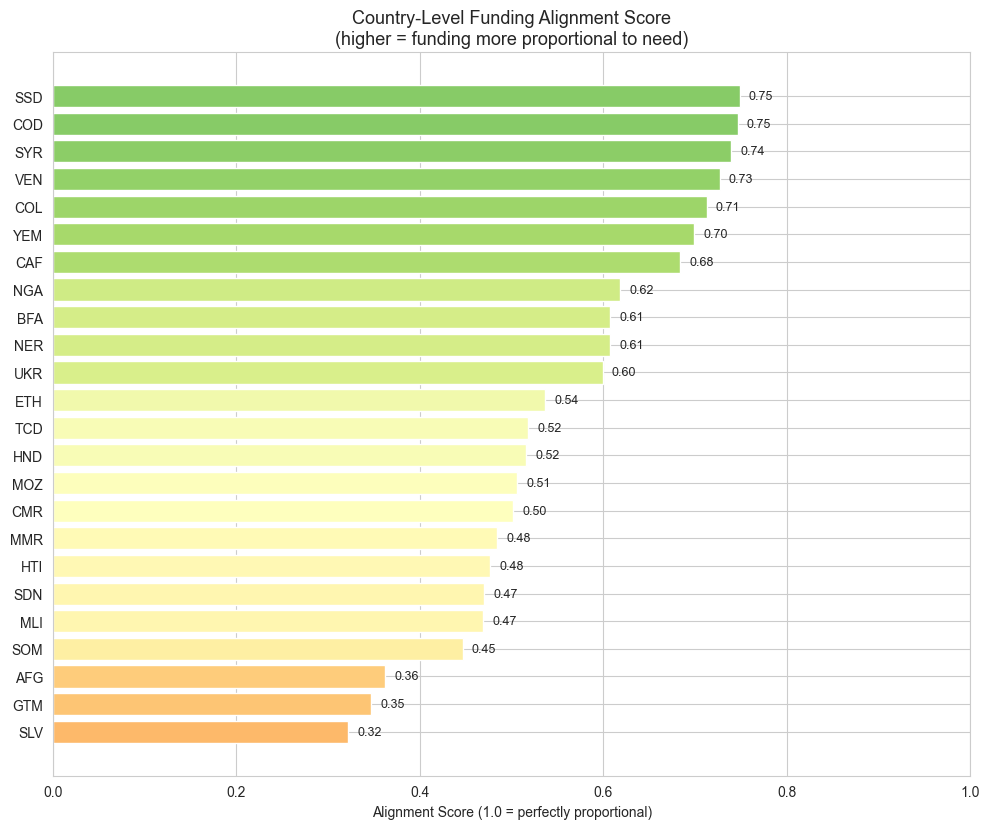

In [16]:
scores_sorted = scores.sort_values("alignment_score")
bar_colors = plt.cm.RdYlGn(scores_sorted["alignment_score"])

fig, ax = plt.subplots(figsize=(10, max(6, len(scores_sorted) * 0.35)))
ax.barh(scores_sorted["country"], scores_sorted["alignment_score"],
        color=bar_colors, edgecolor="white")
ax.set_xlim(0, 1)
ax.set_xlabel("Alignment Score (1.0 = perfectly proportional)")
ax.set_title("Country-Level Funding Alignment Score\n"
             "(higher = funding more proportional to need)", fontsize=13)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.5)

for i, (_, row) in enumerate(scores_sorted.iterrows()):
    ax.text(row["alignment_score"] + 0.01, i, f"{row['alignment_score']:.2f}",
            va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Limitations

 - One immediate limitation which jumps out is a lack of granularity. The HNO and CERF + CBPT datasets actually had more detailed information about the clusters (for example in some places protection was split into child and adult protections) which is an important consideration since the more granular you get the more specifically specific underfunded crisis can get funded. However, at some point data which is too granular becomes harder to interpret and use as a tool to inform decisions at a larger scale, hence why this level of granularity was chosen. 

 - Similar to the point above, the granularity of the countries was left at a country level. This is also incredibly important since different parts of different countries will have different requirements and different clusters underfunded. While this is important enough to potentially run a more granular analysis regarding geography and also still be very interpretable, the reason we ended up not going more granular was because such specific data about funding to specific parts of each country was not available to us. 

 - The data above is based purely on the CERF and CBPT funding, whereas OCHA is not the only organization which funds humanitarian aid. Hence, while a program might be underfunded in terms of the OCHA contributions, it might have enough funding from elsewhere. The reason the rest of the funding was not included is because we wanted to center purely on OCHA funding contributions to inform their process independently as well as possible. To account for this limitation, we have also conducted a analysis using FTS data in a separate part which includes all humanitarian funding, not just OCHA.

---
## Global sector summary

A final summary table showing, for each sector, its needs-weighted mean alignment ratio and how many countries it appears in.

In [18]:
summary = alignment.copy()
total_pin = summary["pin"].sum()
summary["global_weight"] = summary["pin"] / total_pin
summary["w_ratio"] = summary["alignment_ratio"] * summary["global_weight"]

sector_summary = summary.groupby("cluster").agg(
    w_ratio=("w_ratio", "sum"),
    weight=("global_weight", "sum"),
    n_countries=("country", "nunique"),
)
sector_summary["mean_alignment"] = sector_summary["w_ratio"] / sector_summary["weight"]
sector_summary["status"] = sector_summary["mean_alignment"].apply(
    lambda x: "UNDERFUNDED" if x < 1 else "OVERFUNDED"
)
sector_summary = sector_summary[["mean_alignment", "n_countries", "status"]].sort_values("mean_alignment")
sector_summary

,mean_alignment,n_countries,status
cluster,,,
Education,0.332197,22,UNDERFUNDED
CCCM,0.691298,15,UNDERFUNDED
Protection,0.750173,24,UNDERFUNDED
WASH,0.813819,24,UNDERFUNDED
Shelter/NFI,0.876359,22,UNDERFUNDED
Health,0.989368,24,UNDERFUNDED
Food Security,1.397438,24,OVERFUNDED
Nutrition,1.598490,22,OVERFUNDED
Multi-Sector,3.279504,12,OVERFUNDED
